# Import Libraries

In [1]:
# ── Data manipulation ──────────────────────────────────────
import pandas as pd
import numpy as np
import datetime

# ── Visualization ──────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Utility ────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Display configuration ──────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'       : 120,
    'figure.figsize'   : (12, 5),
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'DejaVu Sans'
})

print("All libraries imported successfully!")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   matplotlib : {plt.matplotlib.__version__}")
print(f"   seaborn    : {sns.__version__}")

All libraries imported successfully!
   pandas     : 2.2.2
   numpy      : 2.0.2
   matplotlib : 3.10.0
   seaborn    : 0.13.2


# Read all table from dataset

In [2]:
# Connect To Gdrive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Read All Table

# Read all tables with latin-1 encoding (fixes UnicodeDecodeError)
df_sales         = pd.read_csv('/content/drive/MyDrive/Dibimbing/Finpro/Dataset/Sales.csv',         encoding='latin-1')
df_stores        = pd.read_csv('/content/drive/MyDrive/Dibimbing/Finpro/Dataset/Stores.csv',        encoding='latin-1')
df_customers     = pd.read_csv('/content/drive/MyDrive/Dibimbing/Finpro/Dataset/Customers.csv',     encoding='latin-1')
df_products      = pd.read_csv('/content/drive/MyDrive/Dibimbing/Finpro/Dataset/Products.csv',      encoding='latin-1')
df_exchange_rate = pd.read_csv('/content/drive/MyDrive/Dibimbing/Finpro/Dataset/Exchange_Rates.csv', encoding='latin-1')

print("All tables loaded successfully!")
for name, df in {'Sales': df_sales, 'Stores': df_stores, 'Customers': df_customers,
                  'Products': df_products, 'Exchange Rate': df_exchange_rate}.items():
    print(f"  {name}: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"\n--- {name} columns ---")
    print(df.info())

All tables loaded successfully!
  Sales: 62,884 rows × 9 columns

--- Sales columns ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62884 entries, 0 to 62883
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Order Number   62884 non-null  int64 
 1   Line Item      62884 non-null  int64 
 2   Order Date     62884 non-null  object
 3   Delivery Date  13165 non-null  object
 4   CustomerKey    62884 non-null  int64 
 5   StoreKey       62884 non-null  int64 
 6   ProductKey     62884 non-null  int64 
 7   Quantity       62884 non-null  int64 
 8   Currency Code  62884 non-null  object
dtypes: int64(6), object(3)
memory usage: 4.3+ MB
None
  Stores: 67 rows × 5 columns

--- Stores columns ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   StoreKey       67 non-null 

In [4]:
tables = {
    'Sales'         : df_sales,
    'Products'      : df_products,
    'Customers'     : df_customers,
    'Stores'        : df_stores,
    'Exchange Rates': df_exchange_rate
}

In [5]:
print("🔍 MISSING VALUES PER TABEL\n")

for name, df in tables.items():
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
    missing_df = pd.DataFrame({
        'Missing Value': missing,
        'Persentase (%)' : missing_pct
    })
    missing_df = missing_df[missing_df['Missing Value'] > 0]

    print(f"\n📌 {name}")
    if missing_df.empty:
        print("   ✅ No Missing Value")
    else:
        print(missing_df.to_string())
        print(f"   ⚠️ Problem Column: {len(missing_df)}")

🔍 MISSING VALUES PER TABEL


📌 Sales
               Missing Value  Persentase (%)
Delivery Date          49719           79.06
   ⚠️ Problem Column: 1

📌 Products
   ✅ No Missing Value

📌 Customers
            Missing Value  Persentase (%)
State Code             10            0.07
   ⚠️ Problem Column: 1

📌 Stores
               Missing Value  Persentase (%)
Square Meters              1            1.49
   ⚠️ Problem Column: 1

📌 Exchange Rates
   ✅ No Missing Value


In [6]:
summary_rows = []
for name, df in tables.items():
    total_cells  = df.shape[0] * df.shape[1]
    missing_vals = df.isnull().sum().sum()
    dup_rows     = df.duplicated().sum()
    completeness = round((1 - missing_vals / total_cells) * 100, 2)

    summary_rows.append({
        'Table'              : name,
        'Rows'               : df.shape[0],
        'Column'             : df.shape[1],
        'Missing Values'     : missing_vals,
        'Duplicates'         : dup_rows,
        'Completeness (%)'   : completeness
    })

summary_df = pd.DataFrame(summary_rows).set_index('Table')
display(summary_df)

,Rows,Column,Missing Values,Duplicates,Completeness (%)
Table,,,,,
Sales,62884,9,49719,0,91.22
Products,2517,10,0,0,100.00
Customers,15266,10,10,0,99.99
Stores,67,5,1,0,99.70
Exchange Rates,11215,3,0,0,100.00


1. CLEAN DATAFRAME SALES

In [7]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62884 entries, 0 to 62883
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Order Number   62884 non-null  int64 
 1   Line Item      62884 non-null  int64 
 2   Order Date     62884 non-null  object
 3   Delivery Date  13165 non-null  object
 4   CustomerKey    62884 non-null  int64 
 5   StoreKey       62884 non-null  int64 
 6   ProductKey     62884 non-null  int64 
 7   Quantity       62884 non-null  int64 
 8   Currency Code  62884 non-null  object
dtypes: int64(6), object(3)
memory usage: 4.3+ MB


In [8]:
# Convert date columns to datetime
df_sales['Order Date']    = pd.to_datetime(df_sales['Order Date'],    format='mixed')
df_sales['Delivery Date'] = pd.to_datetime(df_sales['Delivery Date'], format='mixed')

In [9]:
# Flag online orders (no delivery date)
df_sales['Is Online Order'] = df_sales['Delivery Date'].isnull().astype(int)

Check Rellationship Null Delivery Date and StoreKey

In [10]:
# Split sales into two groups
has_delivery = df_sales[df_sales['Delivery Date'].notna()]
no_delivery  = df_sales[df_sales['Delivery Date'].isnull()]

print("=== StoreKey in rows WITH Delivery Date ===")
print(has_delivery['StoreKey'].value_counts())

print("\n=== StoreKey in rows WITHOUT Delivery Date ===")
print(no_delivery['StoreKey'].value_counts())

=== StoreKey in rows WITH Delivery Date ===
StoreKey
0    13165
Name: count, dtype: int64

=== StoreKey in rows WITHOUT Delivery Date ===
StoreKey
9     1577
50    1519
55    1518
54    1498
61    1485
59    1472
45    1471
57    1442
44    1436
65    1395
8     1360
51    1356
64    1353
47    1348
43    1340
66    1295
48    1289
56    1287
53    1284
10    1269
39    1054
40    1050
36    1049
49    1041
38    1034
42    1017
29    1011
37     995
30     976
63     948
5      892
22     800
62     778
27     721
24     703
23     674
19     635
6      615
33     498
32     454
34     448
41     444
20     443
4      431
31     417
21     391
26     295
1      292
15     235
12     224
16     214
28     214
17     210
18     194
13     184
14     126
2       18
Name: count, dtype: int64


In [11]:
# See store details for keys that appear in each group
keys_with_delivery    = has_delivery['StoreKey'].unique()
keys_without_delivery = no_delivery['StoreKey'].unique()

print("=== Store details — WITH Delivery Date ===")
display(df_stores[df_stores['StoreKey'].isin(keys_with_delivery)])

print("\n=== Store details — WITHOUT Delivery Date ===")
display(df_stores[df_stores['StoreKey'].isin(keys_without_delivery)])

=== Store details — WITH Delivery Date ===


,StoreKey,Country,State,Square Meters,Open Date
66,0,Online,Online,NaN,1/1/2010



=== Store details — WITHOUT Delivery Date ===


,StoreKey,Country,State,Square Meters,Open Date
0,1,Australia,Australian Capital Territory,595.00,1/1/2008
1,2,Australia,Northern Territory,665.00,1/12/2008
3,4,Australia,Tasmania,"2,000.00",1/1/2010
4,5,Australia,Victoria,"2,000.00",12/9/2015
5,6,Australia,Western Australia,"2,000.00",1/1/2010
7,8,Canada,Newfoundland and Labrador,"2,105.00",7/2/2014
8,9,Canada,Northwest Territories,"1,500.00",3/4/2005
9,10,Canada,Nunavut,"1,210.00",4/4/2015
11,12,France,Basse-Normandie,350.00,6/6/2012
12,13,France,Corse,245.00,6/7/2013


In [12]:
# See store details for keys that appear in each group
keys_with_delivery    = has_delivery['StoreKey'].unique()
keys_without_delivery = no_delivery['StoreKey'].unique()

print("=== Store details — WITH Delivery Date ===")
display(df_stores[df_stores['StoreKey'].isin(keys_with_delivery)])

print("\n=== Store details — WITHOUT Delivery Date ===")
display(df_stores[df_stores['StoreKey'].isin(keys_without_delivery)])

=== Store details — WITH Delivery Date ===


,StoreKey,Country,State,Square Meters,Open Date
66,0,Online,Online,NaN,1/1/2010



=== Store details — WITHOUT Delivery Date ===


,StoreKey,Country,State,Square Meters,Open Date
0,1,Australia,Australian Capital Territory,595.00,1/1/2008
1,2,Australia,Northern Territory,665.00,1/12/2008
3,4,Australia,Tasmania,"2,000.00",1/1/2010
4,5,Australia,Victoria,"2,000.00",12/9/2015
5,6,Australia,Western Australia,"2,000.00",1/1/2010
7,8,Canada,Newfoundland and Labrador,"2,105.00",7/2/2014
8,9,Canada,Northwest Territories,"1,500.00",3/4/2005
9,10,Canada,Nunavut,"1,210.00",4/4/2015
11,12,France,Basse-Normandie,350.00,6/6/2012
12,13,France,Corse,245.00,6/7/2013


In [13]:
only_in_with    = set(keys_with_delivery) - set(keys_without_delivery)
only_in_without = set(keys_without_delivery) - set(keys_with_delivery)
in_both         = set(keys_with_delivery) & set(keys_without_delivery)

print(f"StoreKeys ONLY in rows with delivery    : {only_in_with}")
print(f"StoreKeys ONLY in rows without delivery : {only_in_without}")
print(f"StoreKeys appearing in BOTH groups      : {in_both}")

print("\n--- Interpretation ---")
if only_in_with:
    print(f"  StoreKey {only_in_with} → likely ONLINE store (always has delivery)")
if only_in_without:
    print(f"  StoreKey {only_in_without} → likely IN-STORE purchase (never has delivery)")
if in_both:
    print(f"  StoreKey {in_both} → mixed, appears in both groups")

StoreKeys ONLY in rows with delivery    : {np.int64(0)}
StoreKeys ONLY in rows without delivery : {np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(59), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66)}
StoreKeys appearing in BOTH groups      : set()

--- Interpretation ---
  StoreKey {np.int64(0)} → likely ONLI

In [14]:
display(df_stores[df_stores['StoreKey'] == 0])

,StoreKey,Country,State,Square Meters,Open Date
66,0,Online,Online,NaN,1/1/2010


From Relatioship with StoreKey, the data with delivery date coming from only store with ['StoreKey'] = 0. The store with StoreKey 0 have no physical sore which we can see from df_store. So, we can assume that the place is online.

In [15]:
# Create Channel Label Based on StoreKey (Online vs In-store)
df_sales['Order Channel'] = df_sales['StoreKey'].apply(
    lambda x: 'Online' if x == 0 else 'In-Store'
)

In [16]:
# Delivery Days — only meaningful for online orders (StoreKey == 0)

df_sales['Delivery Days'] = (df_sales['Delivery Date'] - df_sales['Order Date']).dt.days

In [17]:
# Extra date columns — useful for Power BI time intelligence
df_sales['Order Year']    = df_sales['Order Date'].dt.year
df_sales['Order Month']   = df_sales['Order Date'].dt.month
df_sales['Order Month Name'] = df_sales['Order Date'].dt.strftime('%b')

In [18]:
df_sales.head()

,Order Number,Line Item,Order Date,Delivery Date,CustomerKey,StoreKey,ProductKey,Quantity,Currency Code,Is Online Order,Order Channel,Delivery Days,Order Year,Order Month,Order Month Name
0,366000,1,2016-01-01,NaT,265598,10,1304,1,CAD,1,In-Store,NaN,2016,1,Jan
1,366001,1,2016-01-01,2016-01-13,1269051,0,1048,2,USD,0,Online,12.00,2016,1,Jan
2,366001,2,2016-01-01,2016-01-13,1269051,0,2007,1,USD,0,Online,12.00,2016,1,Jan
3,366002,1,2016-01-01,2016-01-12,266019,0,1106,7,CAD,0,Online,11.00,2016,1,Jan
4,366002,2,2016-01-01,2016-01-12,266019,0,373,1,CAD,0,Online,11.00,2016,1,Jan


2. CLEAN DATAFRAME CUSTOMERS

In [19]:
# Check customers with missing State Code
display(df_customers[df_customers['State Code'].isnull()])

,CustomerKey,Gender,Name,City,State Code,State,Zip Code,Country,Continent,Birthday
5304,729681,Female,Rossana Padovesi,Polvica,NaN,Napoli,80035,Italy,Europe,4/18/1981
5316,732289,Male,Indro Piccio,Varcaturo,NaN,Napoli,80014,Italy,Europe,2/24/1949
5372,742042,Male,Amaranto Loggia,Casaferro,NaN,Napoli,80034,Italy,Europe,3/14/1936
5377,742886,Female,Edmonda Capon,Terzigno,NaN,Napoli,80040,Italy,Europe,8/6/1963
5378,743343,Female,Ambra Sagese,Pomigliano D'Arco,NaN,Napoli,80038,Italy,Europe,1/5/1961
5485,759705,Male,Callisto Lo Duca,Casilli,NaN,Napoli,80047,Italy,Europe,8/28/1976
5525,765589,Male,Michelino Lucchesi,Pompei Scavi,NaN,Napoli,80045,Italy,Europe,11/13/1947
5531,766410,Male,Adelmio Beneventi,Licola,NaN,Napoli,80078,Italy,Europe,1/13/1940
5631,781667,Female,Ilda Manna,Napoli,NaN,Napoli,80134,Italy,Europe,5/8/1977
5695,789177,Male,Calogero Folliero,Mariglianella,NaN,Napoli,80030,Italy,Europe,3/3/2000


In [20]:
# Check other Napoli customers that DO have State Code
napoli = df_customers[df_customers['State'] == 'Napoli']

print(f"Total Napoli customers: {len(napoli)}")
print(f"\nState Code distribution for Napoli:")
print(napoli['State Code'].value_counts(dropna=False))

Total Napoli customers: 10

State Code distribution for Napoli:
State Code
NaN    10
Name: count, dtype: int64


In [21]:
# Fill Napoli State Code with 'NA' (Napoli province code — source: Google)
df_customers.loc[df_customers['State'] == 'Napoli', 'State Code'] = 'NA'

# Verify
print(df_customers[df_customers['State'] == 'Napoli'][['State', 'State Code']].head())
print(f"\nRemaining missing State Code: {df_customers['State Code'].isnull().sum()}")

       State State Code
5304  Napoli         NA
5316  Napoli         NA
5372  Napoli         NA
5377  Napoli         NA
5378  Napoli         NA

Remaining missing State Code: 0


3. CLEAN DATAFRAME STORES

In [22]:
# Fill Square Meters for online store (StoreKey 0) with 0, Cause online store literally don't have physical store
df_stores['Square Meters'].fillna(0, inplace=True)

# Verify
print(df_stores[df_stores['StoreKey'] == 0][['StoreKey', 'Square Meters']])
print(f"\nRemaining missing Square Meters: {df_stores['Square Meters'].isnull().sum()}")

    StoreKey  Square Meters
66         0           0.00

Remaining missing Square Meters: 0


# **FINAL CHECK**

In [23]:
print("🔍 MISSING VALUES PER TABEL\n")

for name, df in tables.items():
    # Skip intentional NaN columns
    skip_cols = ['Delivery Date', 'Delivery Days']
    check_cols = [c for c in df.columns if c not in skip_cols]

    missing = df[check_cols].isnull().sum()
    missing_pct = (df[check_cols].isnull().sum() / len(df) * 100).round(2)
    missing_df = pd.DataFrame({
        'Missing Value': missing,
        'Persentase (%)': missing_pct
    })
    missing_df = missing_df[missing_df['Missing Value'] > 0]

    print(f"\n 🚀 {name}")
    if missing_df.empty:
        print("    ✅ No Missing Value")
    else:
        print(missing_df.to_string())
        print(f"    ⚠️  Problem Column: {len(missing_df)}")

🔍 MISSING VALUES PER TABEL


 🚀 Sales
    ✅ No Missing Value

 🚀 Products
    ✅ No Missing Value

 🚀 Customers
    ✅ No Missing Value

 🚀 Stores
    ✅ No Missing Value

 🚀 Exchange Rates
    ✅ No Missing Value


In [24]:
# Change unit prie cost USD and Unit Price USD to numerical format
price_cols = ['Unit Cost USD', 'Unit Price USD']

for col in price_cols:
    df_products[col] = df_products[col].replace('[\$,]', '', regex=True).astype(float)

# Verify
print(df_products[price_cols].dtypes)
print(df_products[price_cols].head())

Unit Cost USD     float64
Unit Price USD    float64
dtype: object
   Unit Cost USD  Unit Price USD
0           6.62           12.99
1           6.62           12.99
2           7.40           14.52
3          11.00           21.57
4          11.00           21.57


# **EDA**

# **Sales Trend Analysis**

In [25]:
print("Sales columns:", df_sales.columns.tolist())
print("Products columns:", df_products.columns.tolist())
print("Exchange Rate columns:", df_exchange_rate.columns.tolist())

Sales columns: ['Order Number', 'Line Item', 'Order Date', 'Delivery Date', 'CustomerKey', 'StoreKey', 'ProductKey', 'Quantity', 'Currency Code', 'Is Online Order', 'Order Channel', 'Delivery Days', 'Order Year', 'Order Month', 'Order Month Name']
Products columns: ['ProductKey', 'Product Name', 'Brand', 'Color', 'Unit Cost USD', 'Unit Price USD', 'SubcategoryKey', 'Subcategory', 'CategoryKey', 'Category']
Exchange Rate columns: ['Date', 'Currency', 'Exchange']


In [26]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ProductKey      2517 non-null   int64  
 1   Product Name    2517 non-null   object 
 2   Brand           2517 non-null   object 
 3   Color           2517 non-null   object 
 4   Unit Cost USD   2517 non-null   float64
 5   Unit Price USD  2517 non-null   float64
 6   SubcategoryKey  2517 non-null   int64  
 7   Subcategory     2517 non-null   object 
 8   CategoryKey     2517 non-null   int64  
 9   Category        2517 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 196.8+ KB


In [27]:
# Merge Sales with Products to get Unit Price USD
df_merged = df_sales.merge(
    df_products[['ProductKey', 'Unit Price USD', 'Unit Cost USD', 'Category', 'Subcategory', 'Brand']],
    on='ProductKey', how='left'
)

# Calculate Revenue
df_merged['Revenue'] = df_merged['Quantity'] * df_merged['Unit Price USD']

print(f"Merged shape : {df_merged.shape}")
print(f"Total Revenue: ${df_merged['Revenue'].sum():,.0f}")
print(f"Total Orders : {df_merged['Order Number'].nunique():,}")

Merged shape : (62884, 21)
Total Revenue: $55,755,480
Total Orders : 26,326


Yearly Revenue and Order Trend

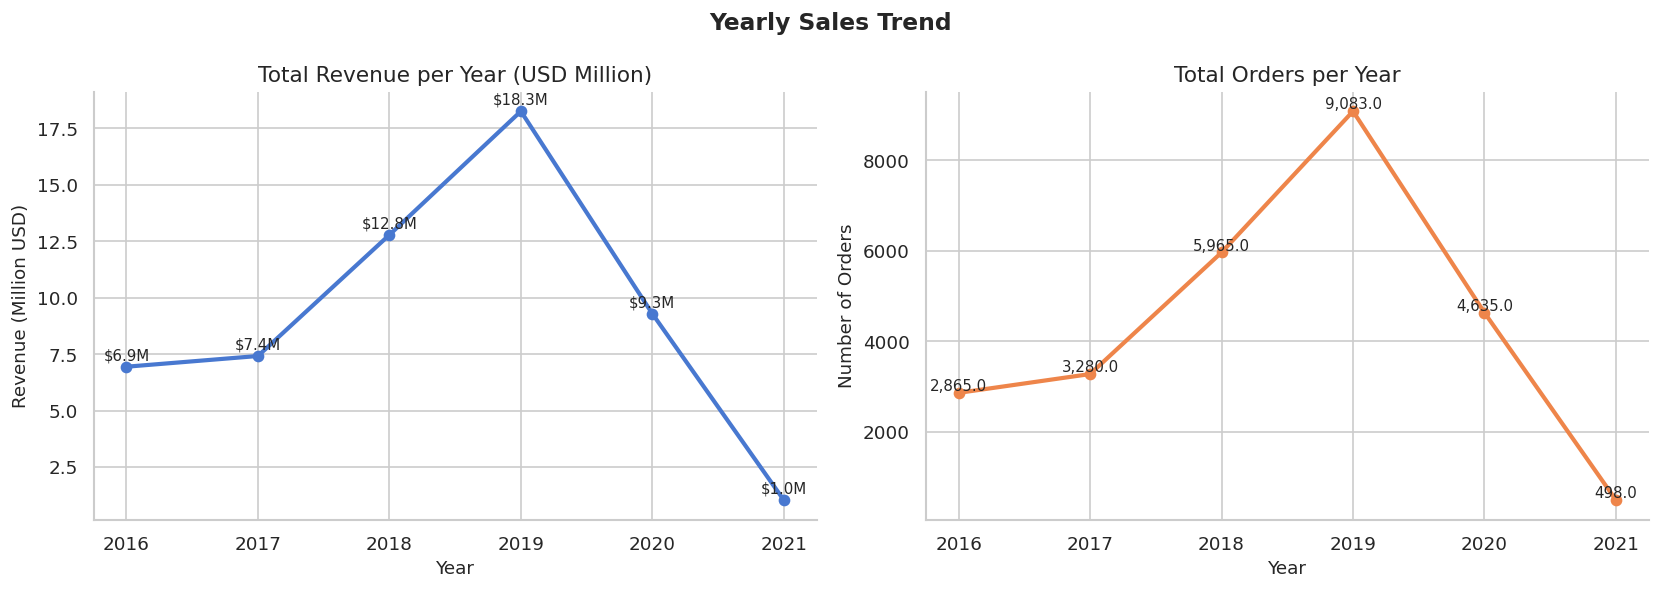

In [28]:
yearly = df_merged.groupby('Order Year').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('Order Number', 'nunique')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Yearly Sales Trend', fontsize=14, fontweight='bold')

# Revenue
axes[0].plot(yearly['Order Year'], yearly['Revenue'] / 1e6,
             marker='o', linewidth=2.5, color=sns.color_palette('muted')[0])
axes[0].set_title('Total Revenue per Year (USD Million)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Revenue (Million USD)')
for _, row in yearly.iterrows():
    axes[0].text(row['Order Year'], row['Revenue']/1e6 + 0.3,
                 f"${row['Revenue']/1e6:.1f}M", ha='center', fontsize=9)

# Orders
axes[1].plot(yearly['Order Year'], yearly['Orders'],
             marker='o', linewidth=2.5, color=sns.color_palette('muted')[1])
axes[1].set_title('Total Orders per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Orders')
for _, row in yearly.iterrows():
    axes[1].text(row['Order Year'], row['Orders'] + 50,
                 f"{row['Orders']:,}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Monthly Revenue Trend

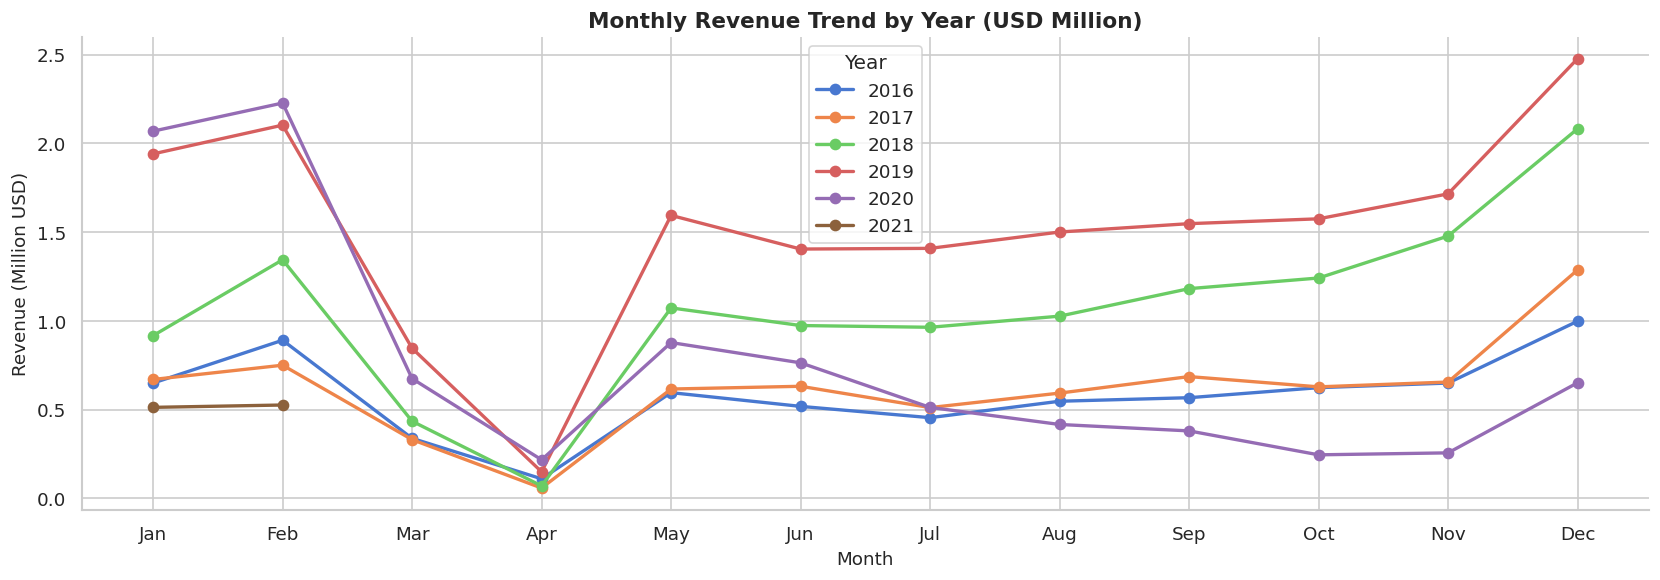

In [29]:
monthly = df_merged.groupby(['Order Year', 'Order Month']).agg(
    Revenue=('Revenue', 'sum')
).reset_index()

# Pivot for multi-line chart
monthly_pivot = monthly.pivot(index='Order Month', columns='Order Year', values='Revenue')

fig, ax = plt.subplots(figsize=(14, 5))
for year in monthly_pivot.columns:
    ax.plot(monthly_pivot.index, monthly_pivot[year] / 1e6,
            marker='o', label=str(year), linewidth=2)

ax.set_title('Monthly Revenue Trend by Year (USD Million)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (Million USD)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend(title='Year')
plt.tight_layout()
plt.show()

Seasonal Pattern

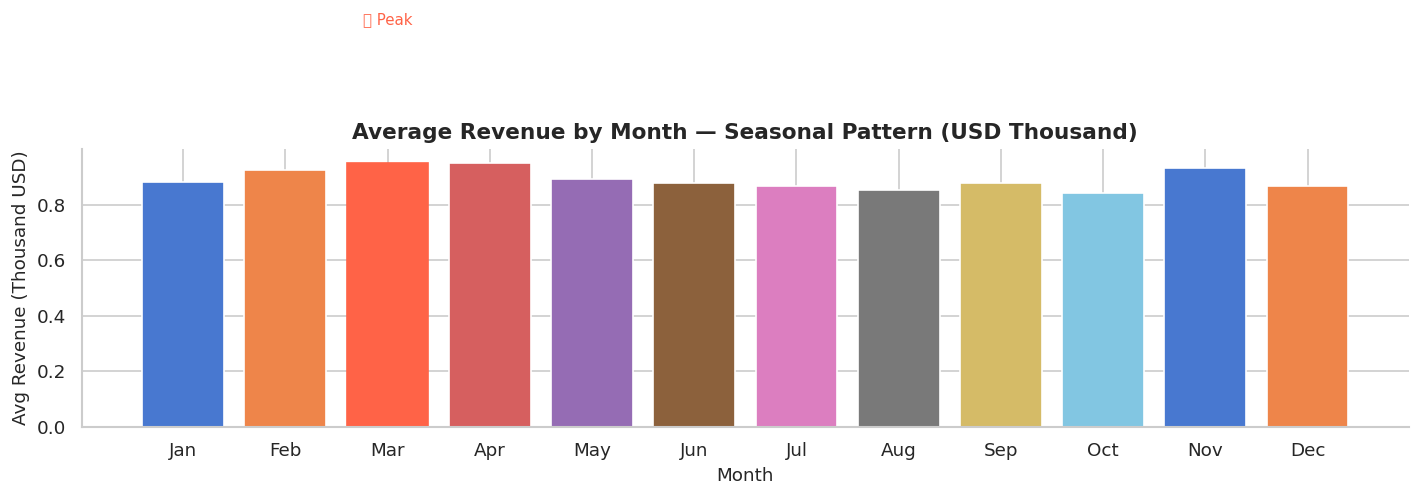

In [30]:
seasonal = df_merged.groupby('Order Month')['Revenue'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonal['Month Name'] = seasonal['Order Month'].apply(lambda x: month_names[x-1])

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(seasonal['Month Name'], seasonal['Revenue'] / 1e3,
              color=sns.color_palette('muted', 12))
ax.set_title('Average Revenue by Month — Seasonal Pattern (USD Thousand)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Revenue (Thousand USD)')

# Highlight peak month
peak = seasonal['Revenue'].idxmax()
bars[peak].set_color('tomato')
ax.text(peak, seasonal['Revenue'].iloc[peak]/1e3 + 0.5,
        '📈 Peak', ha='center', fontsize=9, color='tomato')

plt.tight_layout()
plt.show()

# **Product Analysis**

In [31]:
print(df_products.dtypes)
display(df_products.head())

ProductKey          int64
Product Name       object
Brand              object
Color              object
Unit Cost USD     float64
Unit Price USD    float64
SubcategoryKey      int64
Subcategory        object
CategoryKey         int64
Category           object
dtype: object


,ProductKey,Product Name,Brand,Color,Unit Cost USD,Unit Price USD,SubcategoryKey,Subcategory,CategoryKey,Category
0,1,Contoso 512MB MP3 Player E51 Silver,Contoso,Silver,6.62,12.99,101,MP4&MP3,1,Audio
1,2,Contoso 512MB MP3 Player E51 Blue,Contoso,Blue,6.62,12.99,101,MP4&MP3,1,Audio
2,3,Contoso 1G MP3 Player E100 White,Contoso,White,7.40,14.52,101,MP4&MP3,1,Audio
3,4,Contoso 2G MP3 Player E200 Silver,Contoso,Silver,11.00,21.57,101,MP4&MP3,1,Audio
4,5,Contoso 2G MP3 Player E200 Red,Contoso,Red,11.00,21.57,101,MP4&MP3,1,Audio


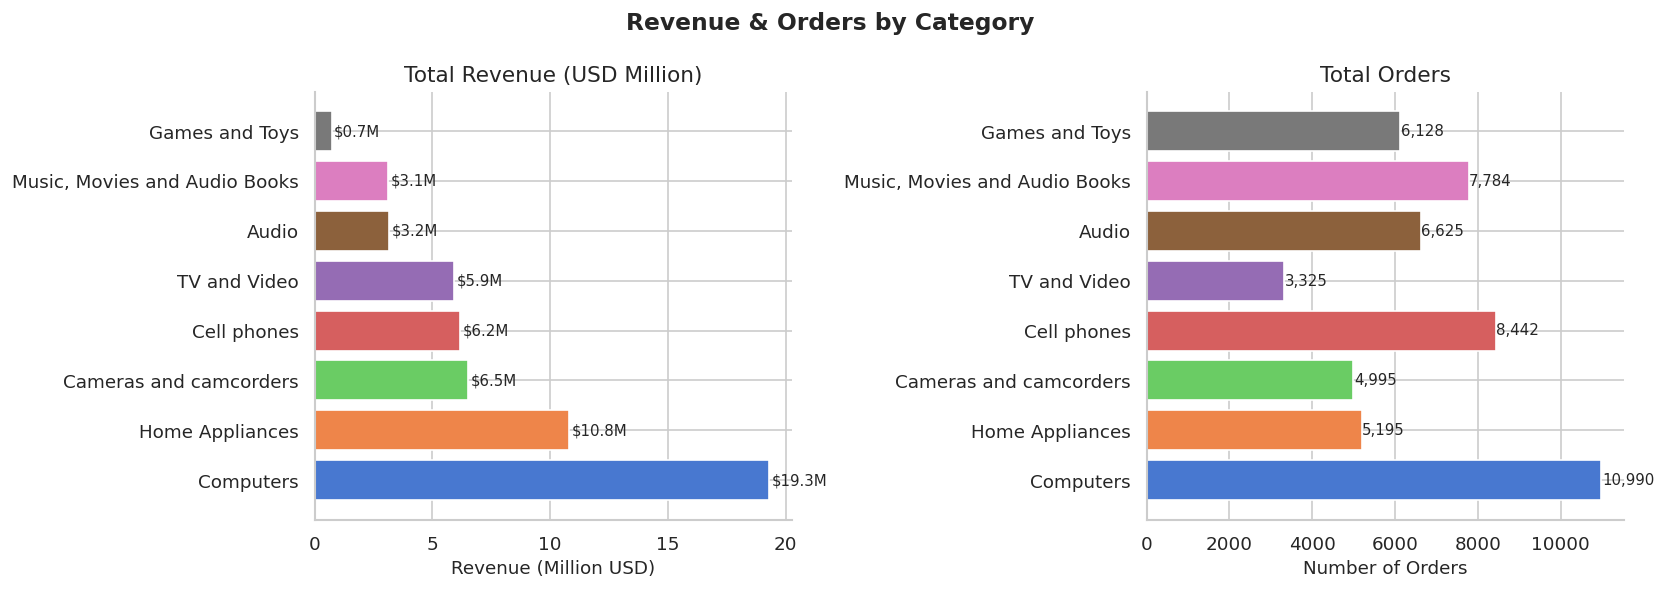

                     Category       Revenue  Orders  Quantity
                    Computers 19,301,595.46   10990     44151
              Home Appliances 10,795,478.59    5195     18401
       Cameras and camcorders  6,520,168.02    4995     17609
                  Cell phones  6,183,791.22    8442     31477
                 TV and Video  5,928,982.69    3325     11236
                        Audio  3,169,627.74    6625     23490
Music, Movies and Audio Books  3,131,006.44    7784     28802
               Games and Toys    724,829.43    6128     22591


In [32]:
# Revenue and quantity by Category
category = df_merged.groupby('Category').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('Order Number', 'nunique'),
    Quantity=('Quantity', 'sum')
).reset_index().sort_values('Revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Revenue & Orders by Category', fontsize=14, fontweight='bold')

# Revenue
axes[0].barh(category['Category'], category['Revenue'] / 1e6,
             color=sns.color_palette('muted', len(category)))
axes[0].set_title('Total Revenue (USD Million)')
axes[0].set_xlabel('Revenue (Million USD)')
for i, (val, cat) in enumerate(zip(category['Revenue'], category['Category'])):
    axes[0].text(val/1e6 + 0.1, i, f"${val/1e6:.1f}M", va='center', fontsize=9)

# Orders
axes[1].barh(category['Category'], category['Orders'],
             color=sns.color_palette('muted', len(category)))
axes[1].set_title('Total Orders')
axes[1].set_xlabel('Number of Orders')
for i, (val, cat) in enumerate(zip(category['Orders'], category['Category'])):
    axes[1].text(val + 10, i, f"{val:,}", va='center', fontsize=9)

plt.tight_layout()
plt.show()
print(category.to_string(index=False))

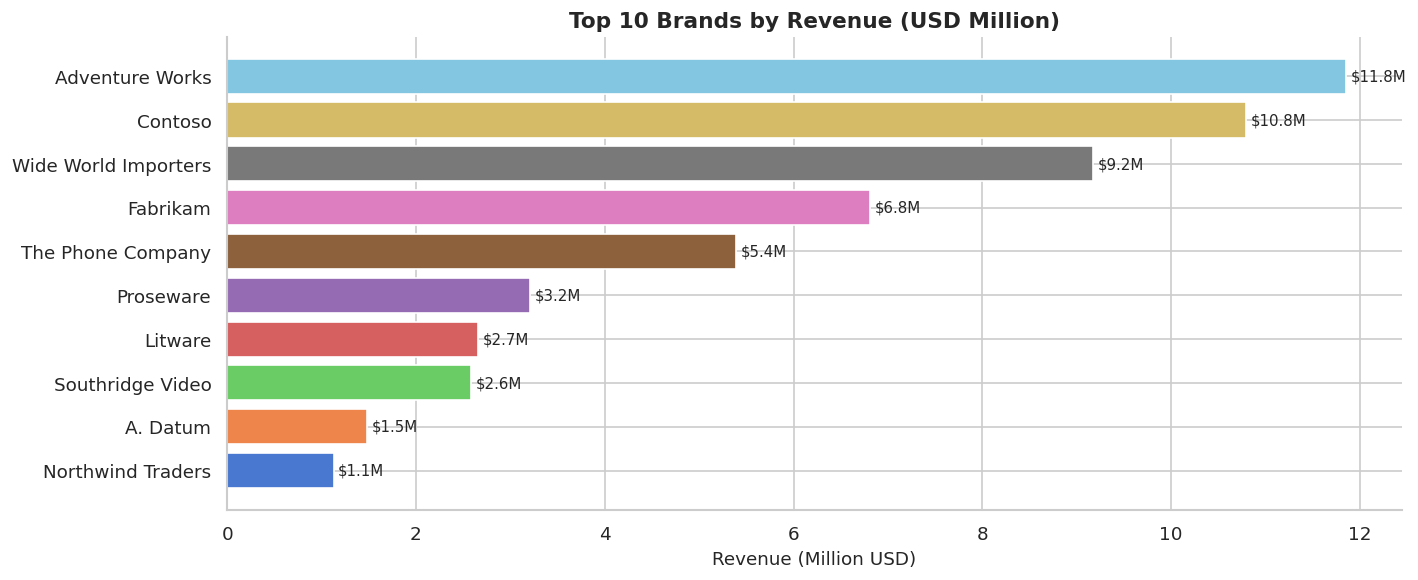

In [33]:
# Top 10 brands by revenue
top_brands = df_merged.groupby('Brand')['Revenue'].sum()\
                       .sort_values(ascending=False).head(10).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_brands['Brand'][::-1], top_brands['Revenue'][::-1] / 1e6,
               color=sns.color_palette('muted', 10))
ax.set_title('Top 10 Brands by Revenue (USD Million)', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (Million USD)')
for i, val in enumerate(top_brands['Revenue'][::-1]):
    ax.text(val/1e6 + 0.05, i, f"${val/1e6:.1f}M", va='center', fontsize=9)

plt.tight_layout()
plt.show()

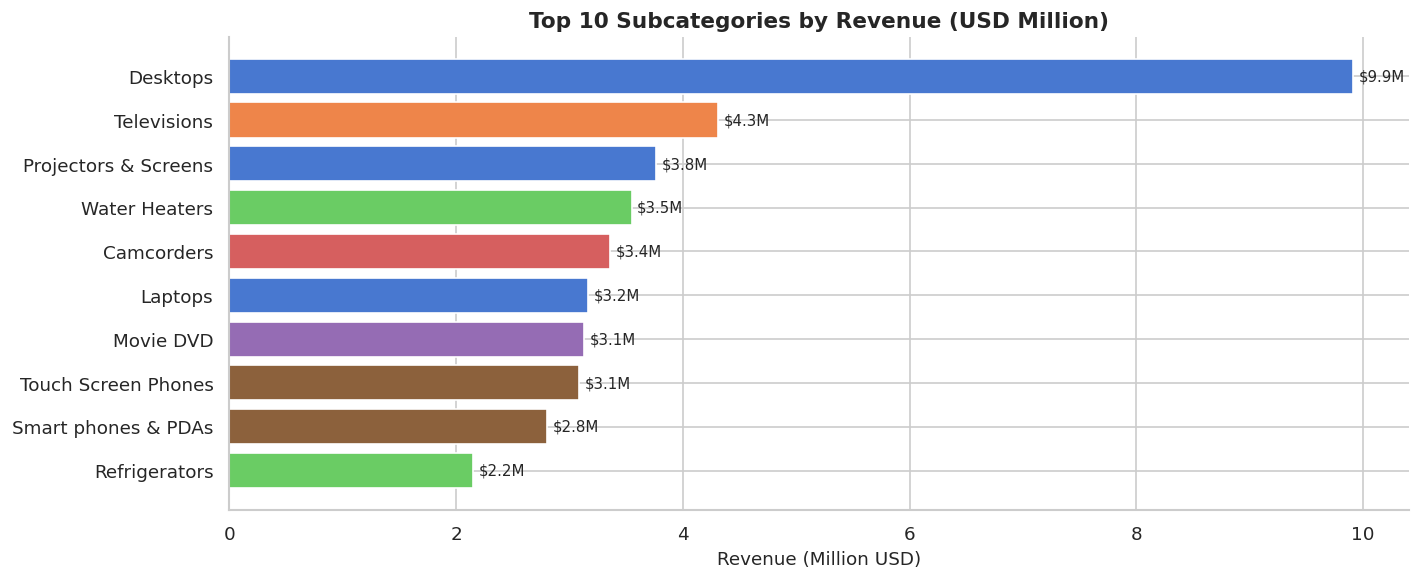

In [34]:
# Top 10 subcategories
top_subcat = df_merged.groupby(['Category', 'Subcategory'])['Revenue'].sum()\
                       .sort_values(ascending=False).head(10).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
colors = sns.color_palette('muted', len(top_subcat['Category'].unique()))
cat_color = {cat: colors[i] for i, cat in enumerate(top_subcat['Category'].unique())}

bars = ax.barh(top_subcat['Subcategory'][::-1], top_subcat['Revenue'][::-1] / 1e6,
               color=[cat_color[c] for c in top_subcat['Category'][::-1]])
ax.set_title('Top 10 Subcategories by Revenue (USD Million)', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (Million USD)')
for i, val in enumerate(top_subcat['Revenue'][::-1]):
    ax.text(val/1e6 + 0.05, i, f"${val/1e6:.1f}M", va='center', fontsize=9)

plt.tight_layout()
plt.show()

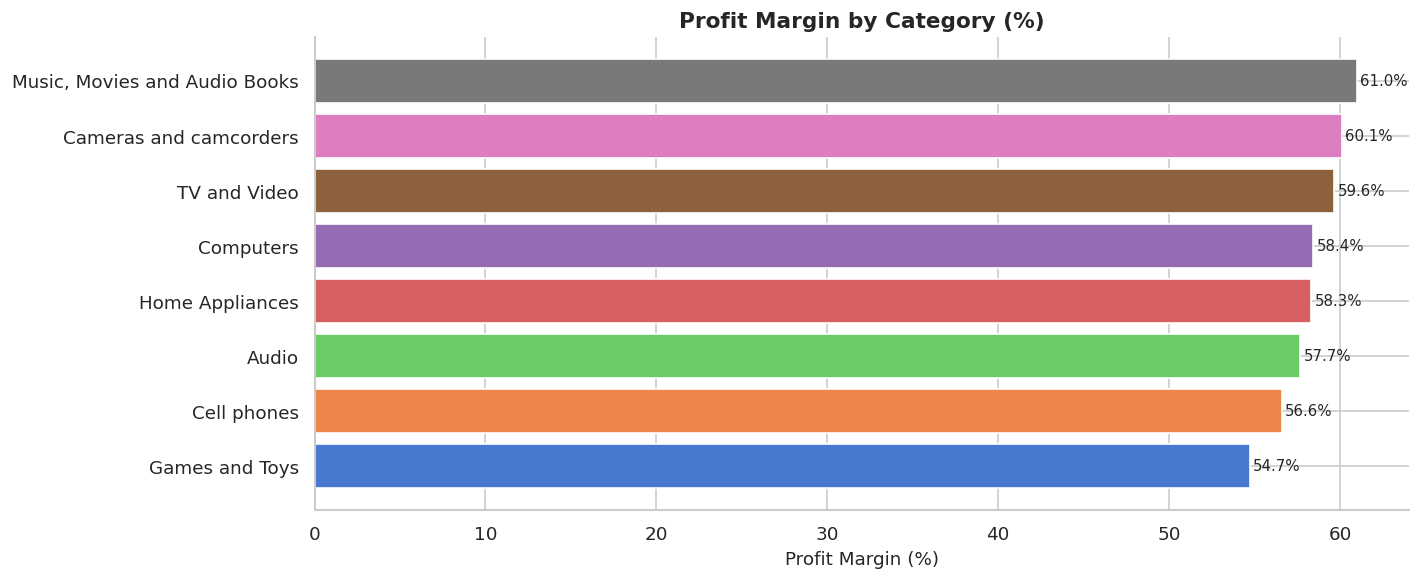

                     Category       Revenue        Profit  Margin (%)
Music, Movies and Audio Books  3,131,006.44  1,909,259.17       60.98
       Cameras and camcorders  6,520,168.02  3,919,800.99       60.12
                 TV and Video  5,928,982.69  3,536,694.39       59.65
                    Computers 19,301,595.46 11,277,447.90       58.43
              Home Appliances 10,795,478.59  6,296,338.85       58.32
                        Audio  3,169,627.74  1,827,851.77       57.67
                  Cell phones  6,183,791.22  3,498,626.54       56.58
               Games and Toys    724,829.43    396,668.77       54.73


In [35]:
# Add profit columns to merged df
df_merged['Cost']   = df_merged['Quantity'] * df_merged['Unit Cost USD']
df_merged['Profit'] = df_merged['Revenue'] - df_merged['Cost']
df_merged['Profit Margin (%)'] = (df_merged['Profit'] / df_merged['Revenue'] * 100).round(2)

# Profit margin by category
margin = df_merged.groupby('Category').agg(
    Revenue=('Revenue', 'sum'),
    Profit=('Profit', 'sum')
).reset_index()
margin['Margin (%)'] = (margin['Profit'] / margin['Revenue'] * 100).round(2)
margin = margin.sort_values('Margin (%)', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(margin['Category'][::-1], margin['Margin (%)'][::-1],
               color=sns.color_palette('muted', len(margin)))
ax.set_title('Profit Margin by Category (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Profit Margin (%)')
for i, val in enumerate(margin['Margin (%)'][::-1]):
    ax.text(val + 0.2, i, f"{val:.1f}%", va='center', fontsize=9)

plt.tight_layout()
plt.show()
print(margin[['Category', 'Revenue', 'Profit', 'Margin (%)']].to_string(index=False))

# **Customer Analysis**

In [36]:
print(df_customers.dtypes)
display(df_customers.head())

CustomerKey     int64
Gender         object
Name           object
City           object
State Code     object
State          object
Zip Code       object
Country        object
Continent      object
Birthday       object
dtype: object


,CustomerKey,Gender,Name,City,State Code,State,Zip Code,Country,Continent,Birthday
0,301,Female,Lilly Harding,WANDEARAH EAST,SA,South Australia,5523,Australia,Australia,7/3/1939
1,325,Female,Madison Hull,MOUNT BUDD,WA,Western Australia,6522,Australia,Australia,9/27/1979
2,554,Female,Claire Ferres,WINJALLOK,VIC,Victoria,3380,Australia,Australia,5/26/1947
3,786,Male,Jai Poltpalingada,MIDDLE RIVER,SA,South Australia,5223,Australia,Australia,9/17/1957
4,1042,Male,Aidan Pankhurst,TAWONGA SOUTH,VIC,Victoria,3698,Australia,Australia,11/19/1965


In [37]:
df_customers['Birthday']    = pd.to_datetime(df_customers['Birthday'],    format='mixed')

In [38]:
# Calculating Age for creating Age bin
# Age will be calculated base on latest order date since the data is historical

latest_order_date = df_merged['Order Date'].max()
df_customers['Age'] = (latest_order_date - df_customers['Birthday']).dt.days // 365

# Create age groups
bins   = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df_customers['Age Group'] = pd.cut(df_customers['Age'], bins=bins, labels=labels)

print(f"Age range      : {df_customers['Age'].min()} – {df_customers['Age'].max()} years")
print(f"\nAge Group distribution:")
print(df_customers['Age Group'].value_counts().sort_index())

Age range      : 19 – 86 years

Age Group distribution:
Age Group
<25      1623
25-34    2262
35-44    2269
45-54    2259
55-64    2324
65+      4529
Name: count, dtype: int64


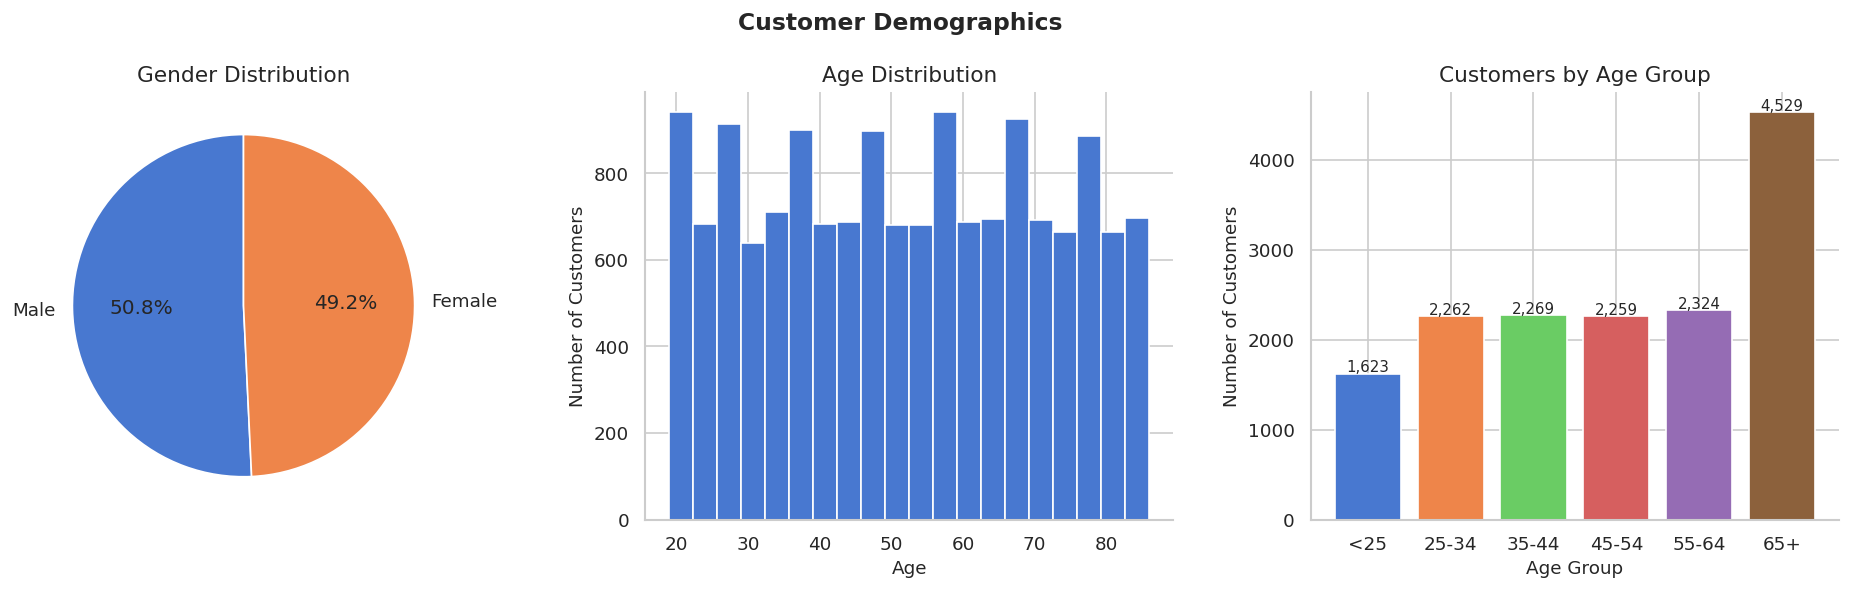

In [39]:
# Gender & Age Distribution

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Customer Demographics', fontsize=14, fontweight='bold')

# Gender distribution — pie chart
gender_counts = df_customers['Gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('muted', len(gender_counts)), startangle=90)
axes[0].set_title('Gender Distribution')

# Age distribution — histogram
axes[1].hist(df_customers['Age'], bins=20, color=sns.color_palette('muted')[0], edgecolor='white')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Number of Customers')

# Age group — bar chart
age_group = df_customers['Age Group'].value_counts().sort_index()
axes[2].bar(age_group.index.astype(str), age_group.values,
            color=sns.color_palette('muted', len(age_group)))
axes[2].set_title('Customers by Age Group')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Number of Customers')
for i, val in enumerate(age_group.values):
    axes[2].text(i, val + 20, f"{val:,}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

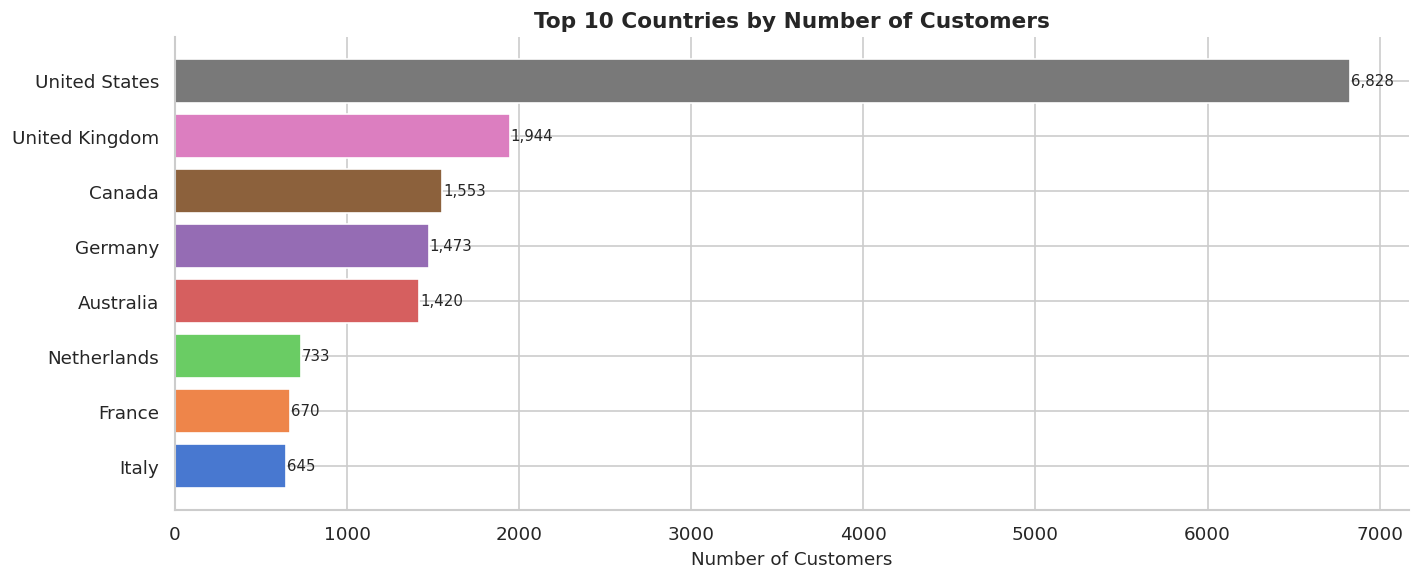

In [40]:
top_countries = df_customers['Country'].value_counts().head(10).reset_index()
top_countries.columns = ['Country', 'Customers']

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_countries['Country'][::-1], top_countries['Customers'][::-1],
        color=sns.color_palette('muted', 10))
ax.set_title('Top 10 Countries by Number of Customers', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Customers')
for i, val in enumerate(top_countries['Customers'][::-1]):
    ax.text(val + 5, i, f"{val:,}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

# **Regional Analysis**

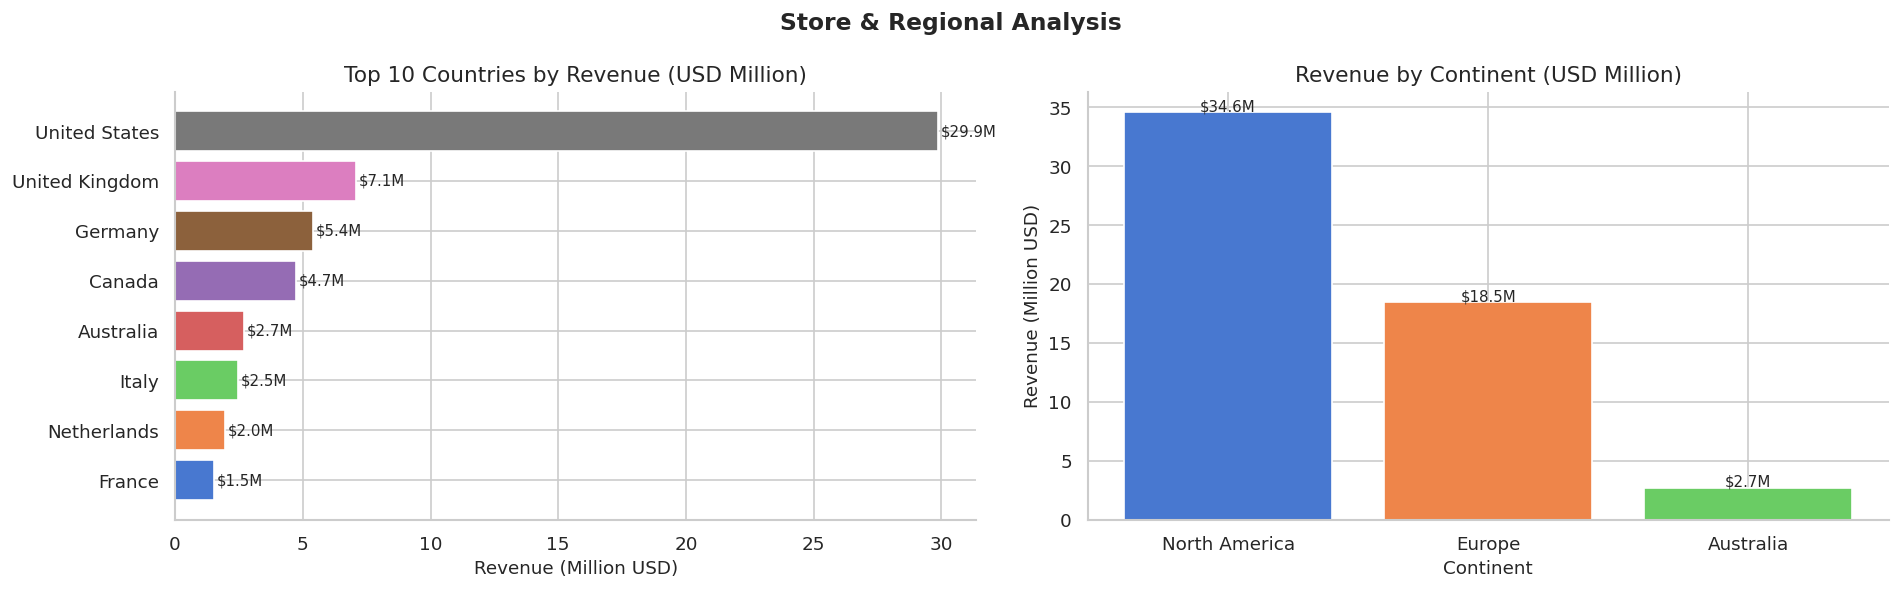

In [41]:
# Merge with customers to get country/continent
df_merged_cust = df_merged.merge(
    df_customers[['CustomerKey', 'Country', 'Continent']],
    on='CustomerKey', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Store & Regional Analysis', fontsize=14, fontweight='bold')

# Top 10 countries by revenue
top_country = df_merged_cust.groupby('Country')['Revenue'].sum()\
                              .sort_values(ascending=False).head(10).reset_index()
axes[0].barh(top_country['Country'][::-1], top_country['Revenue'][::-1] / 1e6,
             color=sns.color_palette('muted', 10))
axes[0].set_title('Top 10 Countries by Revenue (USD Million)')
axes[0].set_xlabel('Revenue (Million USD)')
for i, val in enumerate(top_country['Revenue'][::-1]):
    axes[0].text(val/1e6 + 0.1, i, f"${val/1e6:.1f}M", va='center', fontsize=9)

# Revenue by continent
continent = df_merged_cust.groupby('Continent')['Revenue'].sum()\
                           .sort_values(ascending=False).reset_index()
axes[1].bar(continent['Continent'], continent['Revenue'] / 1e6,
            color=sns.color_palette('muted', len(continent)))
axes[1].set_title('Revenue by Continent (USD Million)')
axes[1].set_xlabel('Continent')
axes[1].set_ylabel('Revenue (Million USD)')
for i, val in enumerate(continent['Revenue']):
    axes[1].text(i, val/1e6 + 0.1, f"${val/1e6:.1f}M", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# **Online VS In-Store Purchase**

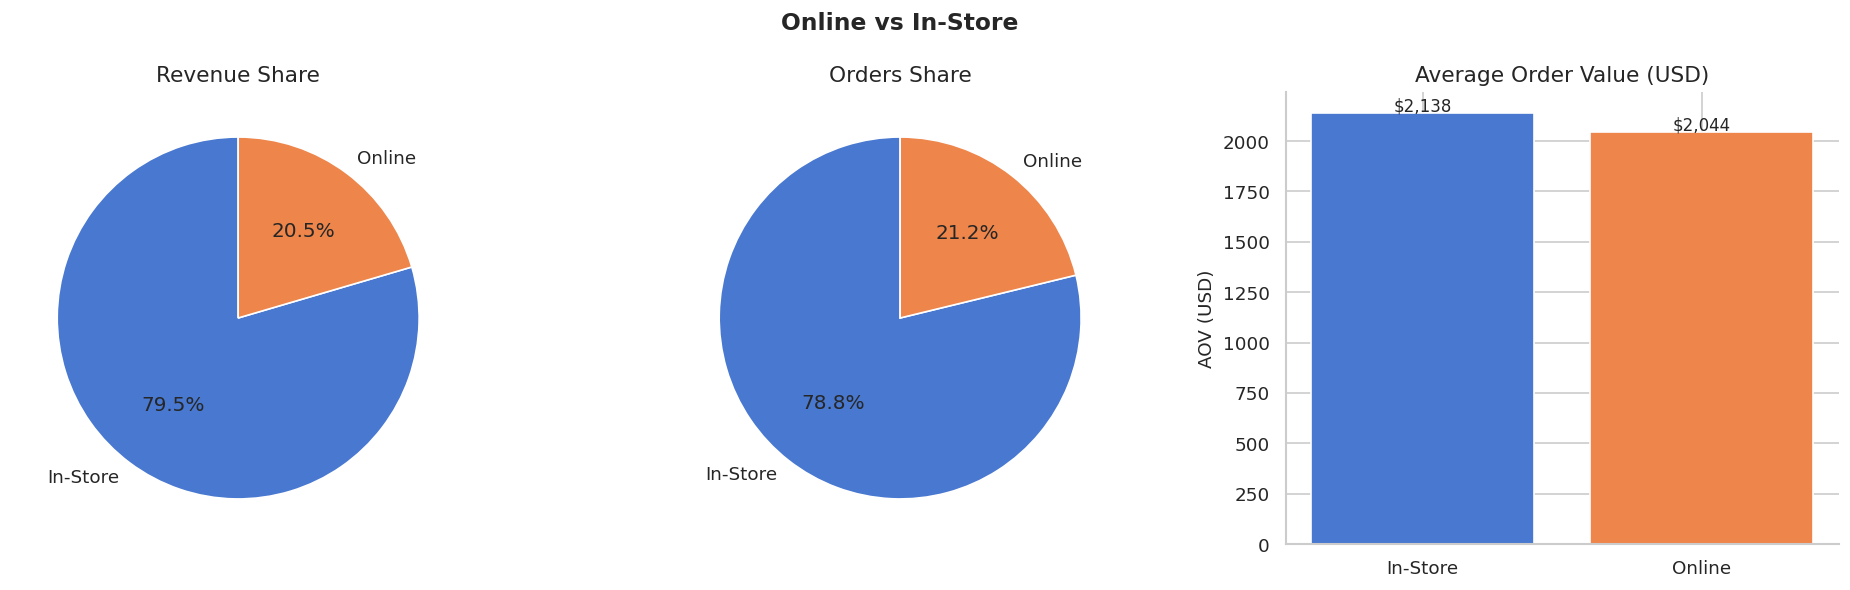

Order Channel       Revenue  Orders  Quantity      AOV
     In-Store 44,351,154.96   20746    156446 2,137.82
       Online 11,404,324.63    5580     41311 2,043.79


In [42]:
channel = df_merged.groupby('Order Channel').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('Order Number', 'nunique'),
    Quantity=('Quantity', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Online vs In-Store', fontsize=14, fontweight='bold')
colors = sns.color_palette('muted', 2)

# Revenue
axes[0].pie(channel['Revenue'], labels=channel['Order Channel'],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Revenue Share')

# Orders
axes[1].pie(channel['Orders'], labels=channel['Order Channel'],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Orders Share')

# AOV — Average Order Value
channel['AOV'] = channel['Revenue'] / channel['Orders']
axes[2].bar(channel['Order Channel'], channel['AOV'],
            color=colors)
axes[2].set_title('Average Order Value (USD)')
axes[2].set_ylabel('AOV (USD)')
for i, val in enumerate(channel['AOV']):
    axes[2].text(i, val + 10, f"${val:,.0f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()
print(channel.to_string(index=False))

# **Delivery Analysis**

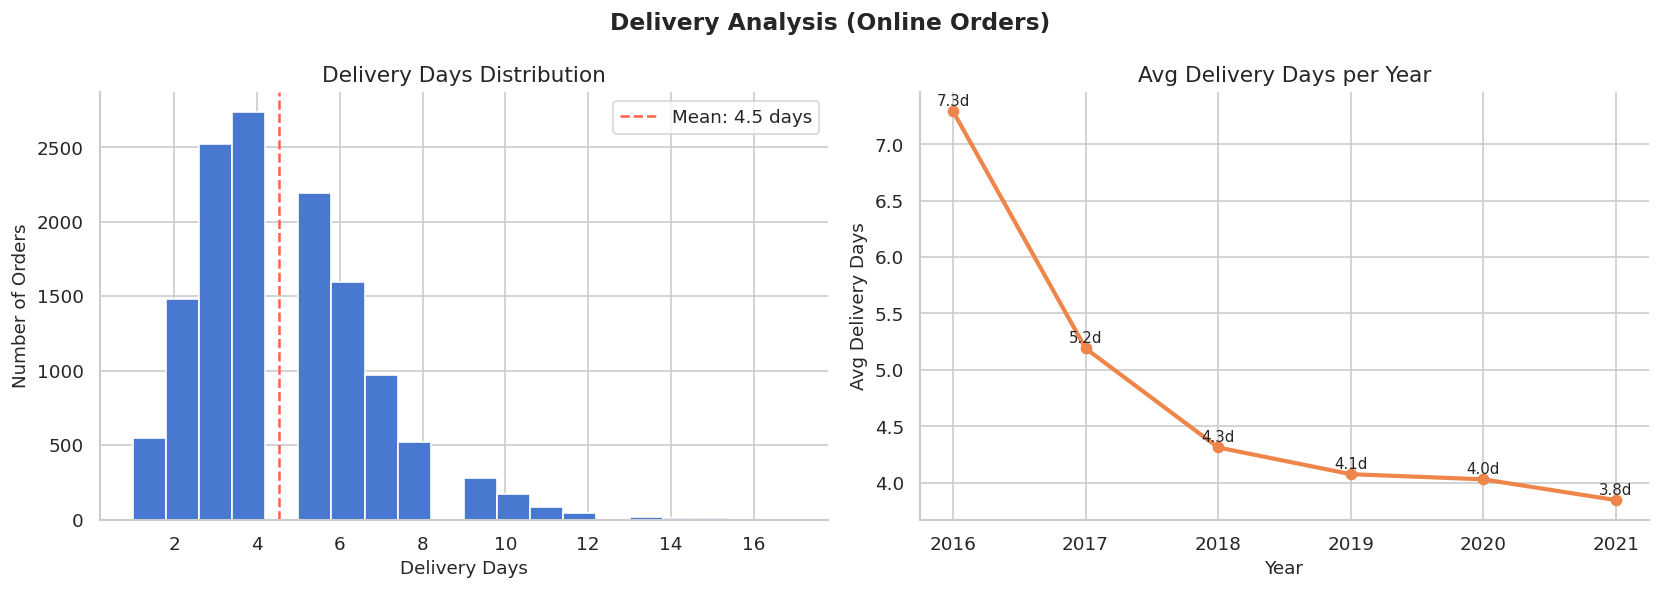


Delivery Stats (Online Orders):
count   13,165.00
mean         4.50
std          2.10
min          1.00
25%          3.00
50%          4.00
75%          6.00
max         17.00
Name: Delivery Days, dtype: float64


In [43]:
# Filter online orders only
online = df_merged[df_merged['Order Channel'] == 'Online'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Delivery Analysis (Online Orders)', fontsize=14, fontweight='bold')

# Distribution of delivery days
axes[0].hist(online['Delivery Days'].dropna(), bins=20,
             color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_title('Delivery Days Distribution')
axes[0].set_xlabel('Delivery Days')
axes[0].set_ylabel('Number of Orders')
axes[0].axvline(online['Delivery Days'].mean(), color='tomato',
                linestyle='--', label=f"Mean: {online['Delivery Days'].mean():.1f} days")
axes[0].legend()

# Average delivery days by year
del_year = online.groupby('Order Year')['Delivery Days'].mean().reset_index()
axes[1].plot(del_year['Order Year'], del_year['Delivery Days'],
             marker='o', linewidth=2.5, color=sns.color_palette('muted')[1])
axes[1].set_title('Avg Delivery Days per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg Delivery Days')
for _, row in del_year.iterrows():
    axes[1].text(row['Order Year'], row['Delivery Days'] + 0.05,
                 f"{row['Delivery Days']:.1f}d", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nDelivery Stats (Online Orders):")
print(online['Delivery Days'].describe().round(1))

# **RFM Segmentation Analysis**

In [44]:
print(df_merged[['Order Number', 'CustomerKey', 'Order Date', 'Revenue']].head())
print(f"\nDate range: {df_merged['Order Date'].min().date()} → {df_merged['Order Date'].max().date()}")

   Order Number  CustomerKey Order Date  Revenue
0        366000       265598 2016-01-01    68.00
1        366001      1269051 2016-01-01   854.00
2        366001      1269051 2016-01-01   665.94
3        366002       266019 2016-01-01 2,254.00
4        366002       266019 2016-01-01   326.00

Date range: 2016-01-01 → 2021-02-20


In [45]:
# Reference Date for recency -> Last purchase + 1 day

ref_date = df_merged['Order Date'].max() + pd.Timedelta(days = 1)

rfm = df_merged.groupby('CustomerKey').agg(
    Recency   = ('Order Date', lambda x: (ref_date - x.max()).days),
    Frequency = ('Order Number', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).reset_index()

print(rfm.head())

   CustomerKey  Recency  Frequency  Monetary
0          301      468          1    592.00
1          325      414          3  5,787.67
2          554      444          2    951.71
3         1042     1083          1  1,124.91
4         1314     1160          1  2,539.86


In [46]:
#Crating Customer Segmentation with 5 bin

# Recency: reverse scoring (5 = most recent)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1]).astype(int)

# Frequency: use rank-based to handle duplicate values
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          q=5, labels=[1,2,3,4,5]).astype(int)

# Monetary: normal scoring (5 = highest spender)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5]).astype(int)

# Combined RFM Score & string
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm[['CustomerKey','Recency','Frequency','Monetary','R_Score','F_Score','M_Score','RFM_Score']].head(10))

   CustomerKey  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0          301      468          1    592.00        3        1        1   
1          325      414          3  5,787.67        4        4        4   
2          554      444          2    951.71        3        2        2   
3         1042     1083          1  1,124.91        1        1        2   
4         1314     1160          1  2,539.86        1        1        3   
5         1568       11          4  4,922.43        5        5        4   
6         1585      724          2  6,700.62        2        2        4   
7         1626      365          2  2,940.35        4        2        3   
8         1642      642          1    115.98        2        1        1   
9         1863      197          2  2,198.25        5        2        3   

  RFM_Score  
0       311  
1       444  
2       322  
3       112  
4       113  
5       554  
6       224  
7       423  
8       211  
9       523  


In [47]:
# Customers with no transactions
cust_with_transactions = df_merged['CustomerKey'].unique()
cust_no_transactions = df_customers[~df_customers['CustomerKey'].isin(cust_with_transactions)]

print(f"Total customers          : {len(df_customers):,}")
print(f"Customers with transactions : {len(cust_with_transactions):,}")
print(f"Customers NO transactions   : {len(cust_no_transactions):,}")

Total customers          : 15,266
Customers with transactions : 11,887
Customers NO transactions   : 3,379


In [48]:
def rfm_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif (r >= 3 and f >= 3 and m >= 3) or (r >= 3 and f >= 2 and m <= 3):
        return 'Loyal'
    elif (r >= 4 and f <= 2) or (r >= 3 and f <= 2):
        return 'Need Attention'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

# Add Inactive
inactive = df_customers[~df_customers['CustomerKey'].isin(rfm['CustomerKey'])][['CustomerKey']].copy()
inactive['Recency']   = None
inactive['Frequency'] = 0
inactive['Monetary']  = 0
inactive['R_Score']   = 0
inactive['F_Score']   = 0
inactive['M_Score']   = 0
inactive['RFM_Score'] = '000'
inactive['Segment']   = 'Inactive'

rfm_full = pd.concat([rfm, inactive], ignore_index=True)

print("Final Segment Distribution:")
print(rfm_full['Segment'].value_counts())
print(f"\nTotal: {len(rfm_full):,} customers")

Final Segment Distribution:
Segment
Loyal             4172
Lost              3410
Inactive          3379
Champions         1912
At Risk           1335
Need Attention    1058
Name: count, dtype: int64

Total: 15,266 customers


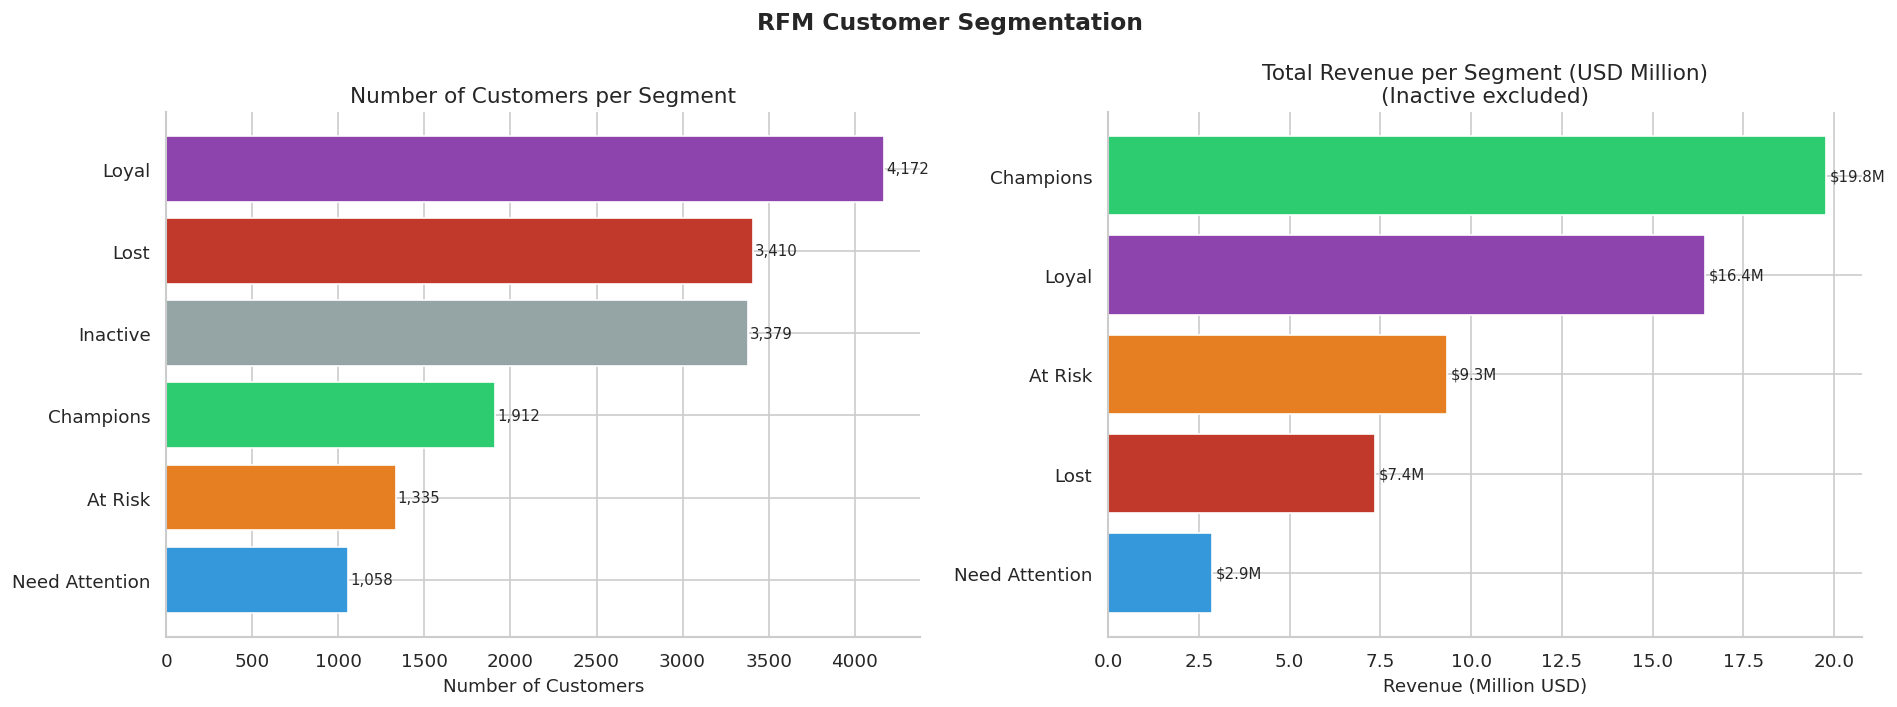

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
1,Champions,1912,260.91,4.10,"10,346.48","19,782,461.03"
3,Loyal,4172,389.18,2.36,"3,939.77","16,436,719.23"
0,At Risk,1335,852.26,2.59,"6,985.59","9,325,765.26"
2,Lost,3410,"1,068.54",1.20,"2,156.94","7,355,167.47"
4,Need Attention,1058,385.83,1.03,"2,698.83","2,855,366.60"


In [49]:
# Define fixed colors per segment
segment_colors = {
    'Champions'     : '#2ecc71',
    'Loyal'         : '#8e44ad',
    'At Risk'       : '#e67e22',
    'Lost'          : '#c0392b',
    'Need Attention': '#3498db',
    'Inactive'      : '#95a5a6',
}

# Segment summary (exclude Inactive for revenue chart)
seg_summary = rfm_full[rfm_full['Segment'] != 'Inactive'].groupby('Segment').agg(
    Customers     = ('CustomerKey', 'count'),
    Avg_Recency   = ('Recency', 'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary', 'mean'),
    Total_Revenue = ('Monetary', 'sum')
).reset_index().sort_values('Total_Revenue', ascending=False)

# Customer count including Inactive
seg_count = rfm_full['Segment'].value_counts().reset_index()
seg_count.columns = ['Segment', 'Customers']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RFM Customer Segmentation', fontsize=14, fontweight='bold')

# Chart 1 — Customer count per segment (including Inactive)
axes[0].barh(seg_count['Segment'][::-1], seg_count['Customers'][::-1],
             color=[segment_colors[s] for s in seg_count['Segment'][::-1]])
axes[0].set_title('Number of Customers per Segment')
axes[0].set_xlabel('Number of Customers')
for i, val in enumerate(seg_count['Customers'][::-1]):
    axes[0].text(val + 10, i, f"{val:,}", va='center', fontsize=9)

# Chart 2 — Total revenue per segment (excluding Inactive)
axes[1].barh(seg_summary['Segment'][::-1], seg_summary['Total_Revenue'][::-1] / 1e6,
             color=[segment_colors[s] for s in seg_summary['Segment'][::-1]])
axes[1].set_title('Total Revenue per Segment (USD Million)\n(Inactive excluded)')
axes[1].set_xlabel('Revenue (Million USD)')
for i, val in enumerate(seg_summary['Total_Revenue'][::-1]):
    axes[1].text(val/1e6 + 0.1, i, f"${val/1e6:.1f}M", va='center', fontsize=9)

plt.tight_layout()
plt.show()
display(seg_summary.round(2))

In [50]:
print("=" * 65)
print("RFM SEGMENT SUMMARY")
print("=" * 65)
display(seg_summary[['Segment','Customers','Avg_Recency',
                      'Avg_Frequency','Avg_Monetary','Total_Revenue']].round(1))

RFM SEGMENT SUMMARY


,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
1,Champions,1912,260.91,4.10,"10,346.50","19,782,461.00"
3,Loyal,4172,389.18,2.40,"3,939.80","16,436,719.20"
0,At Risk,1335,852.26,2.60,"6,985.60","9,325,765.30"
2,Lost,3410,"1,068.54",1.20,"2,156.90","7,355,167.50"
4,Need Attention,1058,385.83,1.00,"2,698.80","2,855,366.60"


In [51]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15266 entries, 0 to 15265
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   CustomerKey  15266 non-null  int64         
 1   Gender       15266 non-null  object        
 2   Name         15266 non-null  object        
 3   City         15266 non-null  object        
 4   State Code   15266 non-null  object        
 5   State        15266 non-null  object        
 6   Zip Code     15266 non-null  object        
 7   Country      15266 non-null  object        
 8   Continent    15266 non-null  object        
 9   Birthday     15266 non-null  datetime64[ns]
 10  Age          15266 non-null  int64         
 11  Age Group    15266 non-null  category      
dtypes: category(1), datetime64[ns](1), int64(2), object(8)
memory usage: 1.3+ MB


# **Export Files**

In [52]:
export_path = '/content/drive/MyDrive/Dibimbing/Finpro/Dataset/Cleaned/'

# # Main tables
# df_sales.to_csv(export_path + 'Sales_cleaned.csv', index=False)
# df_products.to_csv(export_path + 'Products_cleaned.csv', index=False)
# df_customers.to_csv(export_path + 'Customers_cleaned.csv', index=False)
# df_stores.to_csv(export_path + 'Stores_cleaned.csv', index=False)

# # Merged & RFM tables
# rfm_full.to_csv(export_path + 'RFM_Segmentation.csv', index=False)

# print("All files exported successfully!")
# print(f"\nFiles saved to: {export_path}")
# print("  - Sales_cleaned.csv")
# print("  - Products_cleaned.csv")
# print("  - Customers_cleaned.csv")
# print("  - Stores_cleaned.csv")
print("  - RFM_Segmentation.csv")

  - RFM_Segmentation.csv


In [53]:
# Check Adventure Works categories
adventure_works = df_merged[df_merged['Brand'] == 'Adventure Works']

print(f"Total transactions: {len(adventure_works):,}")
print(f"\nRevenue by Category:")
print(adventure_works.groupby('Category')['Revenue'].sum().sort_values(ascending=False))

Total transactions: 6,382

Revenue by Category:
Category
Computers         7,140,884.95
TV and Video      4,308,719.19
Home Appliances     400,305.18
Name: Revenue, dtype: float64


# **CLV Segmentation**

In [54]:
# CLV Tier based on Monetary tercile (active customers only)
active_clv = rfm_full[rfm_full['Segment'] != 'Inactive'].copy()

active_clv['CLV_Tier'] = pd.qcut(
    active_clv['Monetary'],
    q=3,
    labels=['Low Value', 'Medium Value', 'Top Value']
)

print("CLV Tier distribution:")
print(active_clv['CLV_Tier'].value_counts())

# Summary per tier
clv_tier_summary = active_clv.groupby('CLV_Tier', observed=True).agg(
    Customers     = ('CustomerKey', 'count'),
    Total_Revenue = ('Monetary', 'sum'),
    Avg_Revenue   = ('Monetary', 'mean')
).reset_index()

print("\nCLV Tier Summary:")
display(clv_tier_summary.round(2))

# Add CLV_Tier back to rfm_full (Inactive will be NaN)
rfm_full = rfm_full.merge(
    active_clv[['CustomerKey', 'CLV_Tier']], on='CustomerKey', how='left'
)
rfm_full['CLV_Tier'] = rfm_full['CLV_Tier'].astype(str).replace('nan', 'Inactive')

print(f"\nFinal CLV_Tier distribution (incl. Inactive):")
print(rfm_full['CLV_Tier'].value_counts())

# Export
rfm_full.to_csv(export_path + 'RFM_Segmentation.csv', index=False)
print("\nRFM_Segmentation.csv updated with CLV_Tier!")

CLV Tier distribution:
CLV_Tier
Top Value       3963
Low Value       3962
Medium Value    3962
Name: count, dtype: int64

CLV Tier Summary:


,CLV_Tier,Customers,Total_Revenue,Avg_Revenue
0,Low Value,3962,"2,883,523.00",727.79
1,Medium Value,3962,"12,303,796.78","3,105.45"
2,Top Value,3963,"40,568,159.81","10,236.73"



Final CLV_Tier distribution (incl. Inactive):
CLV_Tier
Top Value       3963
Low Value       3962
Medium Value    3962
Inactive        3379
Name: count, dtype: int64

RFM_Segmentation.csv updated with CLV_Tier!


In [55]:
rfm_full.head()

,CustomerKey,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment,CLV_Tier
0,301,468,1,592.00,3,1,1,311,Need Attention,Low Value
1,325,414,3,"5,787.67",4,4,4,444,Champions,Top Value
2,554,444,2,951.71,3,2,2,322,Loyal,Low Value
3,1042,1083,1,"1,124.91",1,1,2,112,Lost,Low Value
4,1314,1160,1,"2,539.86",1,1,3,113,Lost,Medium Value


In [56]:
# Count Loyal customers that are Medium Value
loyal_medium = rfm_full[
    (rfm_full['Segment'] == 'Loyal') &
    (rfm_full['CLV_Tier'] == 'Medium Value')
]

print(f"Loyal + Medium Value: {len(loyal_medium):,} customers")

# Cross check semua kombinasi
print("\nFull cross table:")
print(pd.crosstab(rfm_full['CLV_Tier'], rfm_full['Segment']))

Loyal + Medium Value: 1,835 customers

Full cross table:
Segment       At Risk  Champions  Inactive  Lost  Loyal  Need Attention
CLV_Tier                                                               
Inactive            0          0      3379     0      0               0
Low Value           0          0         0  2066   1347             549
Medium Value      604        230         0   964   1835             329
Top Value         731       1682         0   380    990             180
